In [20]:
import pandas as pd
from xgboost import XGBRegressor
from utils.dfCleaning import Cleaning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.sparse import hstack
from matplotlib import pyplot as plt

----------
# Data Preprocessing and Feature Engineering
----------

In [21]:
df = pd.read_csv('../data/movies.csv')
df = Cleaning(df)
df

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,Z Storm,David Lam,92,Michael Wong,Louis Koo,Stephen Au,Action,7000000,17000000,100.00,100.00,10000000,0,0.0,2014,5.3
3898,Zack and Miri Make a Porno,Kevin Smith,101,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,Comedy,24000000,42000000,66.67,41.66,18000000,0,0.0,2008,6.6
3899,Zero Effect,Jake Kasdan,116,Kim Dickens,Ryan O'Neal,Angela Featherstone,Comedy,5000000,2000000,33.33,50.00,-3000000,0,0.0,1998,7.0
3900,Zombieland,Ruben Fleischer,88,Emma Stone,Bill Murray,Derek Graf,Adventure,23600000,102000000,66.67,33.33,78400000,0,0.0,2009,7.7


### Selecting Features and Target for the Model

In [22]:
X = df[["Budget", "Running time", "Director", "Genre", "Actor 1", "Actor 2", "Actor 3", "Release year", "IMDb score"]]
y = df.loc[:, "Earnings"].values

In [23]:
X["string_features"] = X[["Director", "Genre", "Actor 1", "Actor 2", "Actor 3"]].agg(' '.join, axis=1)
X.drop(columns=["Director", "Genre", "Actor 1", "Actor 2", "Actor 3"], inplace=True)

In [24]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 3902 entries, 0 to 3901
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Budget           3902 non-null   int64  
 1   Running time     3902 non-null   int64  
 2   Release year     3902 non-null   int64  
 3   IMDb score       3902 non-null   float64
 4   string_features  3902 non-null   str    
dtypes: float64(1), int64(3), str(1)
memory usage: 152.6 KB


In [25]:
y

array([ 19400000,  13000000, 119000000, ...,  -3000000,  78400000,
       -11000000], shape=(3902,))

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3121, 5), (781, 5), (3121,), (781,))

### Handling Numerical and Text Features Separately

In [28]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns
num_features

Index(['Budget', 'Running time', 'Release year', 'IMDb score'], dtype='str')

In [29]:
sc = StandardScaler()
X_train_num = sc.fit_transform(X_train[num_features])
X_test_num = sc.transform(X_test[num_features])

In [30]:
tfidf = TfidfVectorizer(max_features=480)
X_train_text = tfidf.fit_transform(X_train["string_features"])
X_test_text = tfidf.transform(X_test["string_features"])

### Combining Numerical and Text Features

In [31]:
X_train_final = hstack([X_train_num, X_train_text])
X_test_final = hstack([X_test_num, X_test_text])

In [32]:
X_train_final.shape, X_test_final.shape

((3121, 484), (781, 484))

---------
# Model Training and Evaluation
---------

In [33]:
regressor = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
regressor.fit(X_train_final, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluating the Model for the Training Set

In [34]:
y_pred_train = regressor.predict(X_train_final)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
print(f"Train MAE: {mae_train}, Train R2: {r2_train}")

Train MAE: 44467836.0, Train R2: 0.8036214113235474


### Evaluating the Model for the Test Set

In [35]:
y_pred_test = regressor.predict(X_test_final)
mse_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
print(f"Test MAE: {mse_test}, Test R2: {r2_test}")

Test MAE: 60760296.0, Test R2: 0.5915476083755493


------------
# Visualizing the Predictions vs Actual Values
-----------

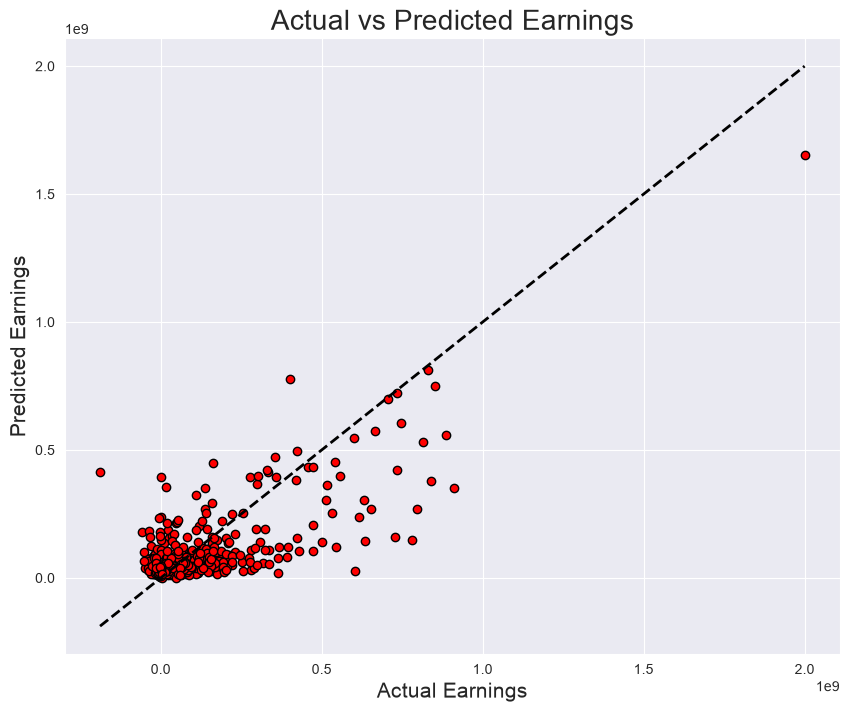

In [36]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, c='red', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Earnings', fontsize=15)
plt.ylabel('Predicted Earnings', fontsize=15)
plt.title('Actual vs Predicted Earnings', fontsize=20)
plt.show()


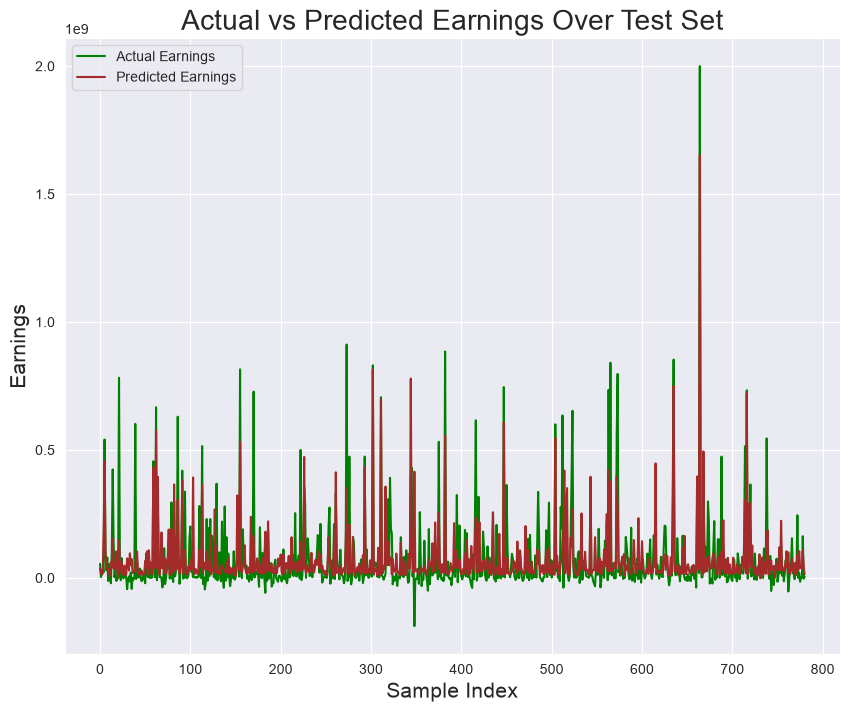

In [37]:
plt.figure(figsize=(10, 8))
plt.plot(y_test, label='Actual Earnings', color='green')
plt.plot(y_pred_test, label='Predicted Earnings', color='brown')
plt.title('Actual vs Predicted Earnings Over Test Set', fontsize=20)
plt.xlabel('Sample Index', fontsize=15)
plt.ylabel('Earnings', fontsize=15)
plt.legend()
plt.show()

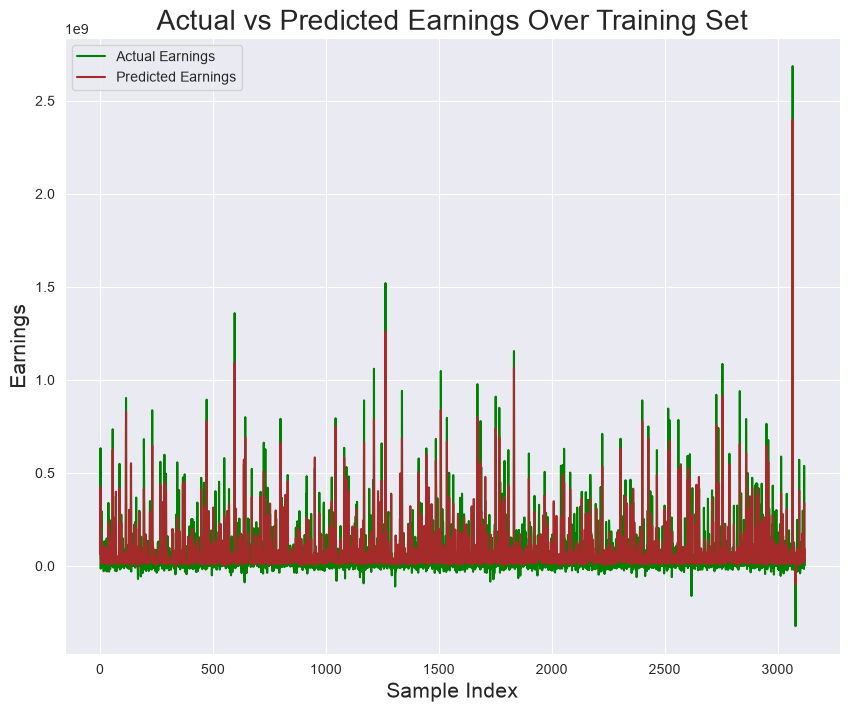

In [38]:
plt.figure(figsize=(10, 8))
plt.plot(y_train, label='Actual Earnings', color='green')
plt.plot(y_pred_train, label='Predicted Earnings', color='brown')
plt.title('Actual vs Predicted Earnings Over Training Set', fontsize=20)
plt.xlabel('Sample Index', fontsize=15)
plt.ylabel('Earnings', fontsize=15)
plt.legend()
plt.show()